In [49]:
from tqdm import tqdm
import time
import pickle
import matplotlib.pyplot as plt
import numqi
import torch
import numpy as np
from utils import HilbertSchmidtMeasure, horodecki_state, depolarizing_channel, GenuineHilbertSchmidtMeasure, hilbert_schmidt_norm, newton_like_method
tableau = ['#006BA4', '#FF800E', '#ABABAB', '#595959', '#5F9ED1', '#C85200', '#898989', '#A2C8EC', '#FFBC79', '#CFCFCF']


# Bound entanglement detection

## BES from Tiles UPB



In [2]:
# Compared with Gilbert algorithm

rho_bes = numqi.entangle.load_upb('tiles', return_bes=True)[1]
model = HilbertSchmidtMeasure(dim_list=[3,3], rank=1, num_ensemble=4*3*3, dtype=torch.complex128)
model.set_target_rho(rho_bes)
theta_optim = numqi.optimize.minimize(model, num_repeat=10, tol=1e-14, print_every_round=0).fun
info_best = model(return_info=True)[1]
print('GEW:', info_best['distance'])
print('Gilbert algorithm:', np.sqrt(0.002177))


GEW: 0.04345491259663206
Gilbert algorithm: 0.04665833258915282


In [3]:
# Check the form of nearest separable state

model = HilbertSchmidtMeasure(dim_list=[3,3], rank=1, num_ensemble=10, dtype=torch.float64)
model.set_target_rho(rho_bes)
theta_optim = numqi.optimize.minimize(model, num_repeat=30, tol=1e-14, print_every_round=0)
info = model(return_info=True)[1]

if abs(info['distance']-info_best['distance'])< 1e-11:
    tmp0 = model.manifold_ensemble_coeff().detach().numpy()
    tmp1 = [x().detach().numpy() for x in model.manifold_psi]
    tmp1 = [x*np.sign(x[:,:1]) for x in tmp1]
    ind0 = np.argsort(tmp0)
    coeff_p = tmp0[ind0]
    coeff_psi = [x[ind0] for x in tmp1]
    coeff_psi_pretty = np.concat([coeff_psi[0], 0*coeff_psi[0][:,:1], coeff_psi[1]], axis=1)
    print(coeff_p) # classical probabilities {p_i}
    print(coeff_psi_pretty) # coefficients of |a_i> and |b_i>, separated by zero column
else:
    print(abs(info['distance']-info_best['distance']))


[0.07571652 0.07571876 0.07572208 0.07572434 0.08767276 0.08767322
 0.13043934 0.13044124 0.13044486 0.13044688]
[[ 0.20159482  0.53117768  0.82292758  0.          0.78851569 -0.38404496
  -0.48036703]
 [ 0.78851736 -0.38404501 -0.48036424  0.          0.82292618  0.53118048
   0.20159315]
 [ 0.48035665  0.38404734 -0.78852085  0.          0.20158568  0.53118705
   0.82292377]
 [ 0.82292297  0.53118899  0.20158386  0.          0.4803544   0.38404802
  -0.78852189]
 [ 0.02175463  0.99952659  0.02175619  0.          0.2725412  -0.92273657
   0.27254086]
 [ 0.27253976 -0.92273693  0.27254106  0.          0.0217545   0.99952661
   0.02175525]
 [ 0.70692206  0.7070765  -0.01743631  0.          0.18997224  0.43704916
  -0.87914651]
 [ 0.18997644  0.43704847 -0.87914594  0.          0.01743385 -0.70707477
  -0.70692385]
 [ 0.87914513 -0.43704857 -0.18997997  0.          0.70692572  0.70707297
  -0.01743136]
 [ 0.01742882 -0.70707163 -0.70692711  0.          0.87914476 -0.43704769
  -0.1899837

# Horodecki state

In [4]:
# Numerical results

model = HilbertSchmidtMeasure(dim_list=[3,3], rank=1, num_ensemble=36, dtype=torch.complex128)
b_list = np.linspace(0, 5, 100)
distance_list = []
witness_list = []
for b in tqdm(b_list):
    rho = horodecki_state(b)
    model.set_target_rho(rho)
    theta_optim = numqi.optimize.minimize(model, num_repeat=3, tol=1e-10, print_every_round=0)
    info = model(return_info=True)[1]
    distance_list.append(info['distance'])

model = HilbertSchmidtMeasure(dim_list=[3,3], rank=1, num_ensemble=36, dtype=torch.complex128)
b_list_finer = np.linspace(2.9, 3.1, 50)
distance_list_finer = []
for b in tqdm(b_list_finer):
    rho = horodecki_state(b)
    model.set_target_rho(rho)
    theta_optim = numqi.optimize.minimize(model, num_repeat=3, tol=1e-14, print_every_round=0)
    info = model(return_info=True)[1]
    distance_list_finer.append(info['distance'])


100%|██████████| 50/50 [01:37<00:00,  1.95s/it]


In [6]:
# save to pkl
# with open('data/horodecki_hs_measure.pkl', 'wb') as f:
#     pickle.dump((b_list, distance_list, b_list_finer, distance_list_finer), f)

# load from pkl
with open('data/horodecki_hs_measure.pkl', 'rb') as f:
    b_list, distance_list, b_list_finer, distance_list_finer = pickle.load(f)


/var/folders/3f/thlrj1xs5yz358grdllkk5vw0000gn/T/ipykernel_67901/2618855889.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


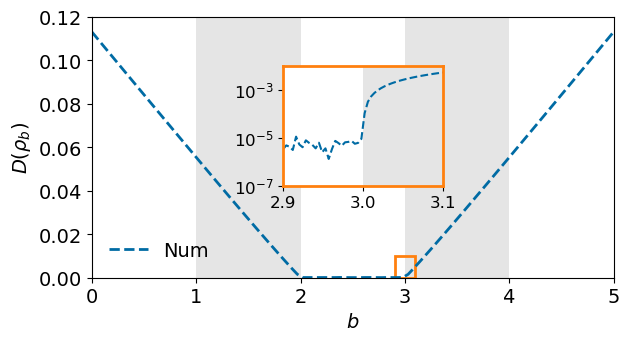

In [34]:
fig, ax = plt.subplots()

ax.plot(b_list, distance_list, color=tableau[0], linewidth=2, label='Num', linestyle='dashed')
ax.fill_between([1, 2], 0, 1, color=tableau[2], alpha=0.3, transform=ax.get_xaxis_transform(), linewidth=0)
ax.fill_between([3, 4], 0, 1, color=tableau[2], alpha=0.3, transform=ax.get_xaxis_transform(), linewidth=0)

ax.set_xlabel(r'$b$', fontsize=14)
ax.set_ylabel(r'$D(\rho_b)$', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim(0, 5)
ax.set_ylim(0, 0.12)
ax.legend(fontsize=14, frameon=False, loc='lower left')
ax.set_box_aspect(0.5)

x_zoom_start, x_zoom_end = 2.9, 3.1
y_zoom_start, y_zoom_end = 10e-8, 0.01

rect = plt.Rectangle((x_zoom_start, y_zoom_start), x_zoom_end - x_zoom_start,
                     y_zoom_end - y_zoom_start, edgecolor=tableau[1], linewidth=2, fill=False)
ax.add_patch(rect)

inset_axes = fig.add_axes([0.45, 0.42, 0.25, 0.25])
inset_axes.plot(b_list_finer, distance_list_finer, color=tableau[0], linewidth=1.5, linestyle='dashed')
inset_axes.fill_between([3, 3.1], 0, 1, color=tableau[2], alpha=0.3, transform=inset_axes.get_xaxis_transform(), linewidth=0)
inset_axes.set_xlim(x_zoom_start, x_zoom_end)
inset_axes.set_ylim(y_zoom_start, y_zoom_end)
inset_axes.tick_params(axis='both', which='major', labelsize=12)
inset_axes.set_yscale('log')
inset_axes.spines['top'].set_color(tableau[1])
inset_axes.spines['right'].set_color(tableau[1])
inset_axes.spines['bottom'].set_color(tableau[1])
inset_axes.spines['left'].set_color(tableau[1])
inset_axes.spines['top'].set_linewidth(2)
inset_axes.spines['bottom'].set_linewidth(2)
inset_axes.spines['left'].set_linewidth(2)
inset_axes.spines['right'].set_linewidth(2)

fig.tight_layout()
# fig.savefig('data/horodecki_state_numerical.pdf', bbox_inches="tight")


# High-dimensional entanglement detection

In [10]:
def unfaithful_state(p):
    d = 4
    basis = [np.eye(d)[i] for i in range(d)]

    psi3 = (np.kron(basis[0], basis[0]) +
            np.kron(basis[1], basis[1]) +
            np.kron(basis[2], basis[2])) / np.sqrt(3)

    psi23 = (np.kron(basis[2], basis[3]) + np.kron(basis[3], basis[2])) / np.sqrt(2)

    rho_psi3 = np.outer(psi3, psi3.conjugate())
    rho_psi23 = np.outer(psi23, psi23.conjugate())

    rho = (1-p) * rho_psi3 + p * rho_psi23
    return rho


In [36]:
rho = unfaithful_state(0.5)
model1 = HilbertSchmidtMeasure(dim_list=[4,4], rank=1, num_ensemble=4*16, dtype=torch.complex128)
model1.set_target_rho(rho)
theta_optim = numqi.optimize.minimize(model1, num_repeat=5, tol=1e-14, print_every_round=0)
info = model1(return_info=True)[1]
print('Visibility Threshold k=2:', info['threshold'])
witness1 = info['witness']

model2 = HilbertSchmidtMeasure(dim_list=[4,4], rank=2, num_ensemble=4*16, dtype=torch.complex128)
model2.set_target_rho(rho)
theta_optim = numqi.optimize.minimize(model2, num_repeat=5, tol=1e-14, print_every_round=0)
info = model2(return_info=True)[1]
witness2 = info['witness']
print('Visibility Threshold k=3:', info['threshold'])


Visibility Threshold k=2: 0.3164266872158378
Visibility Threshold k=3: 0.7499999944679345


In [37]:
p_list = np.linspace(0, 1, 100)
num_list1 = []
num_list2 = []
for p in p_list:
    rho_dep = depolarizing_channel(unfaithful_state(0.5), p)
    num_list1.append(np.trace(witness1 @ rho_dep).real)
    num_list2.append(np.trace(witness2 @ rho_dep).real)


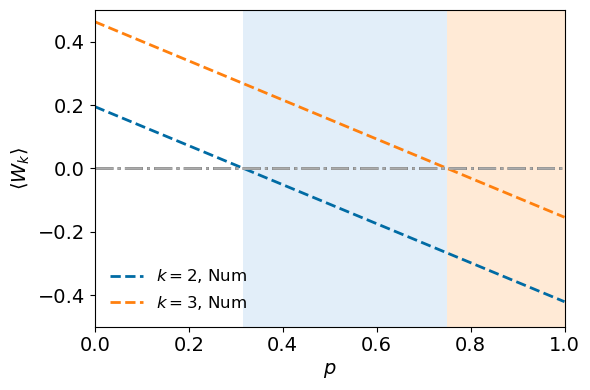

In [38]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between([0.3164, 0.75], 0, 1, color=tableau[7], alpha=0.3, transform=ax.get_xaxis_transform(), linewidth=0)
ax.fill_between([0.75, 1], 0, 1, color=tableau[8], alpha=0.3, transform=ax.get_xaxis_transform(), linewidth=0)
ax.axhline(0, color='black', linestyle='-.', linewidth=2)
ax.plot(p_list, num_list1, label=r'$k=2$, Num', color=tableau[0], linewidth=2, linestyle='dashed'),
ax.plot(p_list, num_list2, label=r'$k=3$, Num', color=tableau[1], linewidth=2, linestyle='dashed')
ax.axhline(0, color=tableau[2], linestyle='-.', linewidth=2)
ax.set_xlabel(r'$p$', fontsize=14)
ax.set_ylabel(r'$\langle W_k \rangle$', fontsize=14)
# lengend larger fontsize
ax.legend(fontsize=12, frameon=False, loc='lower left')
ax.set_xlim(0, 1)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(-0.5, 0.5)
# log scale
# ax.set_yscale('log')
fig.tight_layout()
plt.show()
# fig.savefig('data/high_dimensional_entanglement_numerical.pdf', bbox_inches="tight")


# Multipartite entanglement detection

## Genuine multipartite entanglement

In [40]:
# 3-qubit W state
w3 = numqi.state.W(3)
rho_w3 = w3[:, np.newaxis] @ w3[np.newaxis, :]
model = GenuineHilbertSchmidtMeasure(dim_list=[2,2,2], num_ensemble=2**3, dtype=torch.complex128)
model.set_target_rho(rho_w3)
theta_optim = numqi.optimize.minimize(model, num_repeat=3, tol=1e-10, print_every_round=0)
info = model(return_info=True)[1]
witness_w3 = info['witness']
threshold_w3 = info['threshold']
print('W3 Threshold:', threshold_w3)

w4 = numqi.state.W(4)
rho_w4 = w4[:, np.newaxis] @ w4[np.newaxis, :]
model = GenuineHilbertSchmidtMeasure(dim_list=[2,2,2,2], num_ensemble=2**4, dtype=torch.complex128)
model.set_target_rho(rho_w4)
theta_optim = numqi.optimize.minimize(model, num_repeat=3, tol=1e-10, print_every_round=0)
info = model(return_info=True)[1]
witness_w4 = info['witness']
threshold_w4 = info['threshold']
print('W4 Threshold:', threshold_w4)

p_list = np.linspace(0, 1, 50)
num_w3_list = []
for p in p_list:
    rho_dep = depolarizing_channel(rho_w3, p)
    num_w3_list.append(np.trace(witness_w3 @ rho_dep).real)

num_w4_list = []
for p in p_list:
    rho_dep = depolarizing_channel(rho_w4, p)
    num_w4_list.append(np.trace(witness_w4 @ rho_dep).real)


W3 Threshold: 0.541420726960196
W4 Threshold: 0.6666666677511712


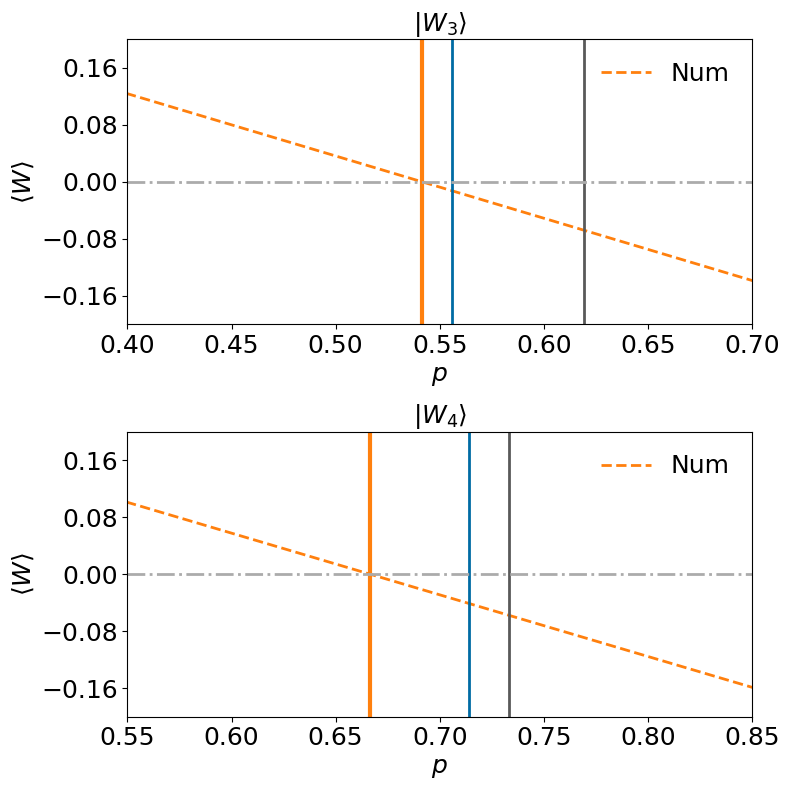

In [42]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
fig.subplots_adjust(hspace=0)
axes[0].plot(p_list, num_w3_list, color=tableau[1], label='Num', linewidth=2, linestyle='dashed')
axes[0].axvline(0.556, color=tableau[0], linestyle='solid', linewidth=2)
axes[0].axvline(0.619, color=tableau[3], linestyle='solid', linewidth=2)
axes[0].axvline(threshold_w3, color=tableau[1], linestyle='solid', linewidth=3)
axes[0].axhline(0, color=tableau[2], linestyle='-.', linewidth=2)
axes[0].set_xlabel(r'$p$', fontsize=18)
axes[0].set_ylabel(r'$\langle W \rangle$', fontsize=18)
axes[0].set_xlim(0.4, 0.7)
axes[0].set_ylim(-0.2, 0.2)
axes[0].tick_params(axis='both', which='major', labelsize=18)
axes[0].legend(fontsize=18, frameon=False)
axes[0].set_title(r'$|W_3\rangle$', fontsize=18)
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

axes[1].plot(p_list, num_w4_list, color=tableau[1], label='Num', linewidth=2, linestyle='dashed')
axes[1].axvline(0.714, color=tableau[0], linestyle='solid', linewidth=2)
axes[1].axvline(0.733, color=tableau[3], linestyle='solid', linewidth=2)
axes[1].axvline(threshold_w4, color=tableau[1], linestyle='solid', linewidth=3)
axes[1].axhline(0, color=tableau[2], linestyle='-.', linewidth=2)
axes[1].set_xlabel(r'$p$', fontsize=18)
axes[1].set_ylabel(r'$\langle W \rangle$', fontsize=18)
axes[1].set_xlim(0.55, 0.85)
axes[1].tick_params(axis='both', which='major', labelsize=18)
axes[1].legend(fontsize=18, frameon=False)
axes[1].set_title(r'$|W_4\rangle$', fontsize=18)
axes[1].set_ylim(-0.2, 0.2)
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

fig.tight_layout()
# fig.savefig('data/genuine_entanglement_numerical.pdf', bbox_inches="tight")


# Complete multipartite entanglement

In [26]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)  # Pauli-X
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)  # Pauli-Y
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)  # Pauli-Z
identity = np.eye(2, dtype=complex)  #  I

def tensor_product(*matrices):
    result = matrices[0]
    for matrix in matrices[1:]:
        result = np.kron(result, matrix)
    return result

identity_4 = tensor_product(identity, identity, identity, identity)
sigma_x_4 = tensor_product(sigma_x, sigma_x, sigma_x, sigma_x)
sigma_y_4 = tensor_product(sigma_y, sigma_y, sigma_y, sigma_y)
sigma_z_4 = tensor_product(sigma_z, sigma_z, sigma_z, sigma_z)
rho_S = (1/16) * (identity_4 + sigma_x_4 + sigma_y_4 + sigma_z_4)


In [27]:
p_list = np.linspace(0, 1, 20)
distance1_list = []
distance2_list = []
distance3_list = []
distance4_list = []
model1 = HilbertSchmidtMeasure(dim_list=[2,2,2,2], rank=1, num_ensemble=4*16, dtype=torch.complex128)
model2 = HilbertSchmidtMeasure(dim_list=[2,8], rank=1, num_ensemble=4*16, dtype=torch.complex128)
model3 = HilbertSchmidtMeasure(dim_list=[2,2,4], rank=1, num_ensemble=4*16, dtype=torch.complex128)
model4 = HilbertSchmidtMeasure(dim_list=[4,4], rank=1, num_ensemble=4*16, dtype=torch.complex128)
for p in tqdm(p_list):
    rho_dep = depolarizing_channel(rho_S, p)
    model1.set_target_rho(rho_dep)
    theta_optim = numqi.optimize.minimize(model1, num_repeat=10, tol=1e-14, print_every_round=0)
    info = model1(return_info=True)[1]
    distance1_list.append(info['distance'])
    model2.set_target_rho(rho_dep)
    theta_optim = numqi.optimize.minimize(model2, num_repeat=10, tol=1e-14, print_every_round=0)
    info = model2(return_info=True)[1]
    distance2_list.append(info['distance'])
    model3.set_target_rho(rho_dep)
    theta_optim = numqi.optimize.minimize(model3, num_repeat=10, tol=1e-14, print_every_round=0)
    info = model3(return_info=True)[1]
    distance3_list.append(info['distance'])
    model4.set_target_rho(rho_dep)
    theta_optim = numqi.optimize.minimize(model4, num_repeat=10, tol=1e-14, print_every_round=0)
    info = model4(return_info=True)[1]
    distance4_list.append(info['distance'])


100%|██████████| 20/20 [02:06<00:00,  6.35s/it]


In [28]:
# save to pkl
# with open('data/smolin_hs_measure.pkl', 'wb') as f:
#     pickle.dump((p_list, distance1_list, distance2_list, distance3_list, distance4_list), f)

# load from pkl
with open('data/smolin_hs_measure.pkl', 'rb') as f:
    p_list, distance1_list, distance2_list, distance3_list, distance4_list = pickle.load(f)


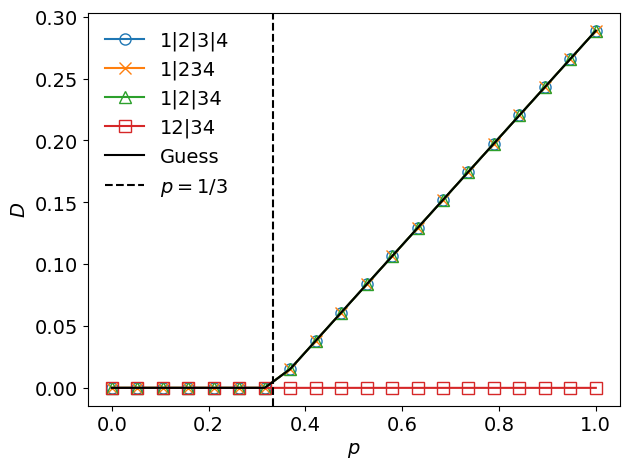

In [29]:
distance_guess_list = [np.sqrt(3)/4*(p-1/3) if p>1/3 else 0 for p in p_list]

fig, ax = plt.subplots()
ax.plot(p_list, distance1_list, marker='o', label='1|2|3|4', markerfacecolor='none', markersize=8)
ax.plot(p_list, distance2_list, marker='x', label='1|234', markerfacecolor='none', markersize=8)
ax.plot(p_list, distance3_list, marker='^', label='1|2|34', markerfacecolor='none', markersize=8)
ax.plot(p_list, distance4_list, marker='s', label='12|34', markerfacecolor='none', markersize=8)
ax.plot(p_list, distance_guess_list, color='k', label='Guess')
ax.axvline(1/3, color='k', linestyle='dashed', label=r'$p=1/3$')
ax.set_xlabel(r'$p$', fontsize=14)
ax.set_ylabel(r'$D$', fontsize=14)
ax.legend(fontsize=14, frameon=False)
ax.tick_params(axis='both', which='major', labelsize=14)
# log scale
# ax.set_yscale('log')
fig.tight_layout()
# fig.savefig('data/smolin_hs_measure.pdf', bbox_inches="tight")


# Isotropic state

In [30]:
def isotropic_state(d, F):
    psi_plus = numqi.state.maximally_entangled_state(d)
    rho_psi_plus = psi_plus[:, np.newaxis] @ psi_plus[np.newaxis, :]
    identity = np.eye(d*d, dtype=complex)
    rho = F * rho_psi_plus + (1-F)*(identity-rho_psi_plus)/ (d**2 -1)
    return rho


In [ ]:
dim_list = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
time_list = []
error_list = []
for d in dim_list:
    model = HilbertSchmidtMeasure(dim_list=[d, d], rank=1, num_ensemble=2*d*d, dtype=torch.complex128)
    F_list = np.linspace(1/d, 1, 101)[1:]
    time_sublist = []
    error_sublist = []
    for F in tqdm(F_list):
        rho = isotropic_state(d, F)
        model.set_target_rho(rho)
        start_time = time.time()
        theta_optim = numqi.optimize.minimize(model, num_repeat=3, tol=1e-12, print_every_round=0)
        end_time = time.time()
        info = model(return_info=True)[1]
        time_sublist.append(end_time - start_time)
        ret = info['distance']
        error_sublist.append(np.abs(ret - hilbert_schmidt_norm(rho - isotropic_state(d, 1/d))))
    # add average time and error for this dimension
    time_list.append(np.mean(time_sublist))
    error_list.append(np.mean(error_sublist))


In [32]:
# save to pkl
# with open('data/hs_measure_isotropic_time_error.pkl', 'wb') as f:
#     pickle.dump((dim_list, time_list, error_list), f)
# load from pkl
with open('data/hs_measure_isotropic_time_error.pkl', 'rb') as f:
    dim_list, time_list, error_list = pickle.load(f)


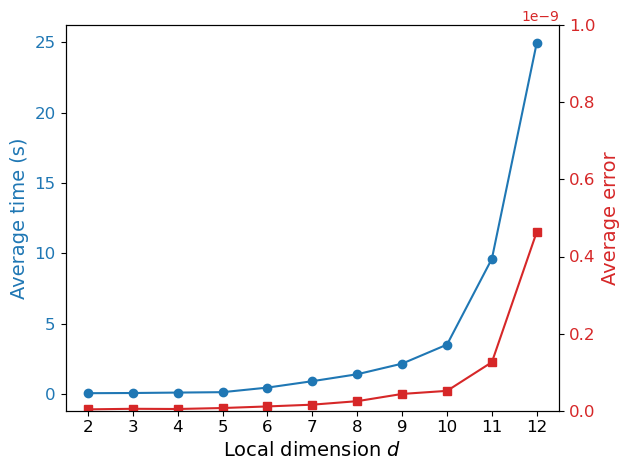

In [33]:
# two y axes plot
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel(r'Local dimension $d$', fontsize=14)
ax1.set_xticks(dim_list)
ax1.set_ylabel('Average time (s)', color=color, fontsize=14)
ax1.plot(dim_list, time_list, marker='o', color=color)
# ax1.plot(dim_list, fit_func(np.array(dim_list), a, b), linestyle='dashed', color='gray', label=f'Fit: {a:.2e} * d^{b:.2f}')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average error', color=color, fontsize=14)
ax2.plot(dim_list, error_list, marker='s', color=color)
ax2.set_ylim(0, 1e-9)
ax2.tick_params(axis='y', labelcolor=color)
ax2.tick_params(axis='y', which='major', labelsize=12)
fig.tight_layout()
# fig.savefig('data/hs_measure_isotropic_time_error.pdf')


# Newton-like method

Optimal threshold: 0.5035722417745869


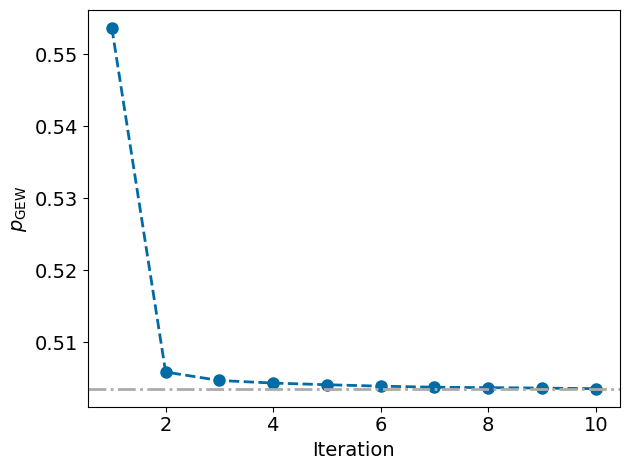

In [43]:
H3 = np.array([1, 0, 1, 0, 1, 0, 0, 1])/2
rho_H3 = H3[:, np.newaxis] @ H3[np.newaxis, :]

threshold_list = newton_like_method(rho_H3, dim_list=[2,2,2], rank=1, max_iter=10, genuine_tag=True)[1]
optimal_threshold = min(threshold_list)
print('Optimal threshold:', optimal_threshold)

fig, ax =plt.subplots()
ax.plot(range(1, len(threshold_list)+1), threshold_list, marker='o', linestyle='dashed', color=tableau[0], linewidth=2, markersize=8)
ax.axhline(optimal_threshold, color=tableau[2], linestyle='-.', linewidth=2)
ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel(r'$p_{\text{GEW}}$', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
fig.tight_layout()


Optimal threshold: 0.4595048265155841


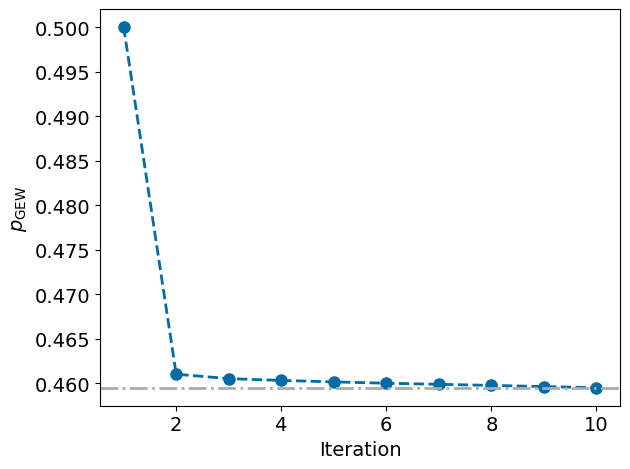

In [44]:
dicke = numqi.state.Dicke(2,2)
rho_dicke = dicke[:, np.newaxis] @ dicke[np.newaxis, :]

threshold_list = newton_like_method(rho_dicke, dim_list=[2,2,2,2], rank=1, max_iter=10, genuine_tag=True)[1]
optimal_threshold = min(threshold_list)
print('Optimal threshold:', optimal_threshold)

fig, ax =plt.subplots()
ax.plot(range(1, len(threshold_list)+1), threshold_list, marker='o', linestyle='dashed', color=tableau[0], linewidth=2, markersize=8)
ax.axhline(optimal_threshold, color=tableau[2], linestyle='-.', linewidth=2)
ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel(r'$p_{\text{GEW}}$', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
fig.tight_layout()


In [47]:
W3 = numqi.state.W(3)
rho_W3 = W3[:, np.newaxis] @ W3[np.newaxis, :]

w3_threshold_list = newton_like_method(rho_W3, dim_list=[2,2,2], rank=1, max_iter=10, genuine_tag=True)[1]
w3_optimal_threshold = min(w3_threshold_list)

W4 = numqi.state.W(4)
rho_W4 = W4[:, np.newaxis] @ W4[np.newaxis, :]

w4_threshold_list = newton_like_method(rho_W4, dim_list=[2,2,2,2], rank=1, max_iter=10, genuine_tag=True)[1]
w4_optimal_threshold = min(w4_threshold_list)


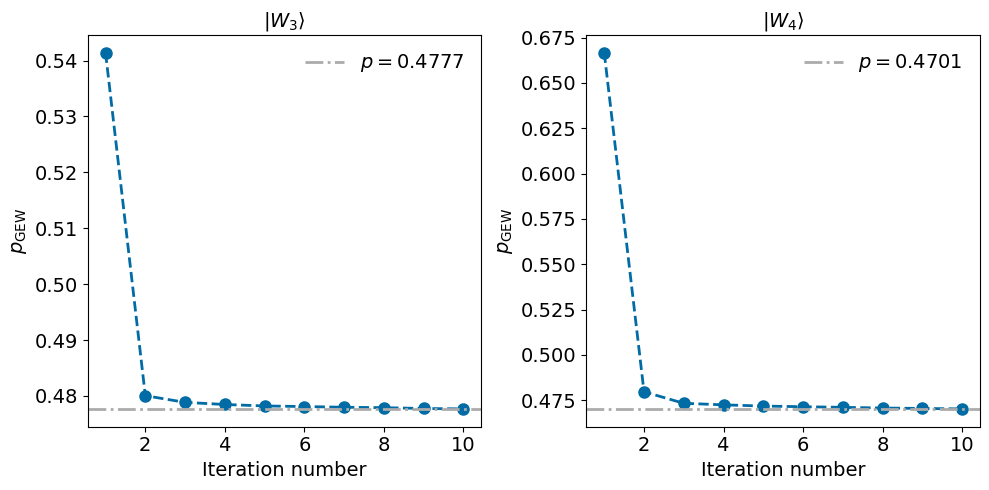

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(range(1, len(w3_threshold_list)+1), w3_threshold_list, marker='o', linestyle='dashed', color=tableau[0], linewidth=2, markersize=8)
axes[0].axhline(w3_optimal_threshold, color=tableau[2], linestyle='-.', linewidth=2, label=r'$p=0.4777$')
axes[0].set_ylabel(r'$p_{\text{GEW}}$', fontsize=14)
axes[0].tick_params(axis='both', which='major', labelsize=14)
axes[0].set_title(r'$|W_3\rangle$', fontsize=14)
axes[0].set_xlabel('Iteration number', fontsize=14)
axes[0].legend(fontsize=14, frameon=False)

axes[1].plot(range(1, len(w4_threshold_list)+1), w4_threshold_list, marker='o', linestyle='dashed', color=tableau[0], linewidth=2, markersize=8)
axes[1].axhline(w4_optimal_threshold, color=tableau[2], linestyle='-.', linewidth=2, label=r'$p=0.4701$')
axes[1].set_ylabel(r'$p_{\text{GEW}}$', fontsize=14)
axes[1].tick_params(axis='both', which='major', labelsize=14)
axes[1].set_title(r'$|W_4\rangle$', fontsize=14)
axes[1].set_xlabel('Iteration number', fontsize=14)
axes[1].legend(fontsize=14, frameon=False)

fig.tight_layout()
# fig.savefig('data/w_state_threshold_improvement.pdf', bbox_inches="tight")
